# Final Model Colab Runner

Stage 1 Transformer VAE 20-fold training and Stage 2 delta-flow training/inference in one notebook.

- `RUN_STAGE1=True`, `RUN_STAGE2=True`: train Stage 1 first, then automatically use the selected fold checkpoint for Stage 2.
- `RUN_STAGE1=False`, `RUN_STAGE2=True`: skip Stage 1 and use an existing checkpoint by setting `STAGE2_EXISTING_FOLD_DIR` and `STAGE2_EXISTING_CKPT`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== Settings =====
PROJECT_DIR = '/content/drive/MyDrive/sleep-edf/final_model'

# Default: skip Stage 1 and run Stage 2 from an existing Stage 1 checkpoint.
RUN_STAGE1 = True
RUN_STAGE2 = True

SEED = 42
EPOCHS = 10
MAX_SUBJECTS = 20   # 0 means all subjects
FOLDS = 20
BATCH_SIZE = 64

FOLD_START = 0
FOLD_END = 20      # None means run to the last fold

TRAIN_SAMPLING = 'shuffle'  # 'shuffle', 'stage_balanced', 'subject_balanced'
KL_WARMUP_EPOCHS = 5
WAKE_LOSS_WEIGHT = 1.0
STAGE_CLASS_WEIGHT_MULTIPLIER = [0.25, 0.55, 1.0, 1.0, 1.0]  # W N1 N2 N3 REM

# Stage 1 VAE loss weights
LAMBDA_REC = 0.3
LAMBDA_SPEC = 0.2
LAMBDA_BAND = 0.1
LAMBDA_SIGMA = 0.05
LAMBDA_STAGE = 3.0
SUBWINDOW_STAGE_LOSS_WEIGHT = 0.5
LAMBDA_KL = 3e-4

USE_CLASS_WEIGHTS = True
NO_PROGRESS = False

SAVE_NAME = 'final_model_stage1_20fold_transformer_vae_w025_n1x055'
SAVE_DIR = f'checkpoints/{SAVE_NAME}'

# Resume Stage 1 only when continuing an interrupted run.
RESUME_FROM_SAVE_DIR = None
RESUME_CHECKPOINT_NAME = 'last_vae.pt'

# ===== Stage 2 settings =====
# If RUN_STAGE1=True, Stage2 uses SAVE_DIR/fold_{STAGE2_FOLD}/best_vae.pt after Stage1 finishes.
# If RUN_STAGE1=False, set STAGE2_EXISTING_FOLD_DIR and STAGE2_EXISTING_CKPT manually.
STAGE2_FOLD = 3
STAGE2_EXISTING_FOLD_DIR = f"{SAVE_DIR}/fold_{STAGE2_FOLD:02d}"
STAGE2_EXISTING_CKPT = f"{STAGE2_EXISTING_FOLD_DIR}/best_vae.pt"
STAGE2_EPOCHS = 10
STAGE2_BATCH_SIZE = 16
STAGE2_CONTEXT_LEN = 5
STAGE2_HORIZONS = 3
STAGE2_FLOW_STEPS = 10
STAGE2_LAMBDA_NEXT_STAGE = 0.5
STAGE2_SAMPLING = 'transition'
STAGE2_MAX_SUBJECTS = 30
STAGE2_TARGET_STAGE_WEIGHT_MULTIPLIER = [1.0, 0.55, 1.0, 1.0, 1.0]  # W N1 N2 N3 REM
STAGE2_SAVE_NAME = 'final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05'
STAGE2_SAVE_DIR = f'checkpoints/{STAGE2_SAVE_NAME}'

# Set True to skip Stage 2 training and run inference/eval from an existing flow checkpoint.
STAGE2_INFER_ONLY = False
STAGE2_FLOW_CKPT = f'{STAGE2_SAVE_DIR}/flow_delta_multi.pt'


In [ ]:
import os, sys, subprocess, json, time
from pathlib import Path

os.chdir(PROJECT_DIR)
print('cwd =', os.getcwd())
print('python =', sys.executable)

# requirements.txt가 있으면 설치합니다.
req = Path('requirements.txt')
if req.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(req)], check=True)
else:
    print('requirements.txt not found; skipping pip install')

cwd = /content/drive/MyDrive/sleep-edf/final_model
python = /usr/bin/python3


In [ ]:
if RUN_STAGE1:
    cmd = [
        sys.executable, 'run_kfold10_stage1.py',
        '--folds', str(FOLDS),
        '--max-subjects', str(MAX_SUBJECTS),
        '--seed', str(SEED),
        '--epochs', str(EPOCHS),
        '--batch-size', str(BATCH_SIZE),
        '--train-sampling', TRAIN_SAMPLING,
        '--kl-warmup-epochs', str(KL_WARMUP_EPOCHS),
        '--wake-loss-weight', str(WAKE_LOSS_WEIGHT),
        '--lambda-rec', str(LAMBDA_REC),
        '--lambda-spec', str(LAMBDA_SPEC),
        '--lambda-band', str(LAMBDA_BAND),
        '--lambda-sigma', str(LAMBDA_SIGMA),
        '--lambda-stage', str(LAMBDA_STAGE),
        '--subwindow-stage-loss-weight', str(SUBWINDOW_STAGE_LOSS_WEIGHT),
        '--lambda-kl', str(LAMBDA_KL),
        '--stage-class-weight-multiplier', *map(str, STAGE_CLASS_WEIGHT_MULTIPLIER),
        '--save-dir', SAVE_DIR,
    ]
    if FOLD_START is not None:
        cmd += ['--fold-start', str(FOLD_START)]
    if FOLD_END is not None:
        cmd += ['--fold-end', str(FOLD_END)]
    if not USE_CLASS_WEIGHTS:
        cmd += ['--no-class-weights']
    if NO_PROGRESS:
        cmd += ['--no-progress']
    if RESUME_FROM_SAVE_DIR:
        cmd += ['--resume-from-save-dir', RESUME_FROM_SAVE_DIR, '--resume-checkpoint-name', RESUME_CHECKPOINT_NAME]

    print(' '.join(cmd), flush=True)
    TRAINING_STARTED = time.perf_counter()
    log_path = Path('stage1_run.log')
    with log_path.open('w', encoding='utf-8') as log_f:
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
            log_f.write(line)
        rc = proc.wait()
    TRAINING_ELAPSED_SECONDS = time.perf_counter() - TRAINING_STARTED
    print(f'\nTotal notebook Stage1 cell time: {TRAINING_ELAPSED_SECONDS / 60:.2f} min ({TRAINING_ELAPSED_SECONDS:.1f} sec)')
    if rc != 0:
        print(f'\nStage1 failed with return code {rc}. Full log: {log_path.resolve()}')
        raise RuntimeError(f'Stage1 failed; inspect {log_path}')
else:
    print('RUN_STAGE1=False: skipping Stage 1 training')


RUN_STAGE1=False: skipping Stage 1 training


summary: checkpoints/final_model_stage1_20fold_transformer_vae_w025_n1x055/kfold20_summary.json

=== Fold mean +/- std ===
test_accuracy: 82.89% +/- 6.79%
test_macro_f1: 62.52% +/- 10.55%

=== Pooled all-fold metrics ===
ACC=82.88% MF1=66.57% WF1=84.63% n=54585
per-class recall: {'W': 0.9024827586206896, 'N1': 0.4636127355425601, 'N2': 0.6928203574674341, 'N3': 0.8941655359565808, 'REM': 0.7525773195876289}

=== Stage 1 all-fold 5-class confusion matrix ===
rows=true cols=pred
labels: ['W', 'N1', 'N2', 'N3', 'REM']
W: [32715, 2254, 90, 94, 1097]
N1: [175, 1427, 583, 28, 865]
N2: [35, 843, 6861, 936, 1228]
N3: [4, 13, 130, 1318, 9]
REM: [77, 572, 303, 8, 2920]
visualization: checkpoints/final_model_stage1_20fold_transformer_vae_w025_n1x055/all_folds_confusion_matrix_colab.png


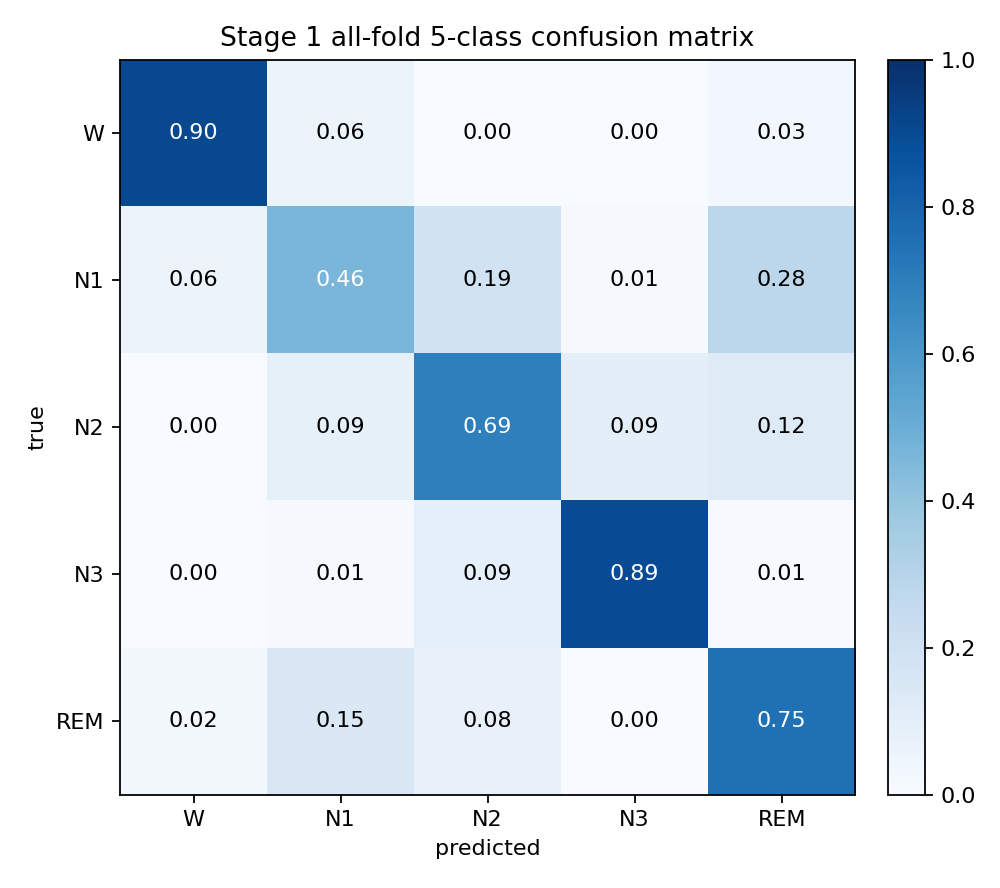


=== Stage 1 all-fold binary Wake/Sleep confusion matrix ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [32715, 3535]
Sleep: [291, 18044]
ACC=92.99% MF1=92.44% WakeRecall=90.25% SleepRecall=98.41% n=54585
visualization: checkpoints/final_model_stage1_20fold_transformer_vae_w025_n1x055/all_folds_binary_wake_sleep_confusion_matrix_colab.png


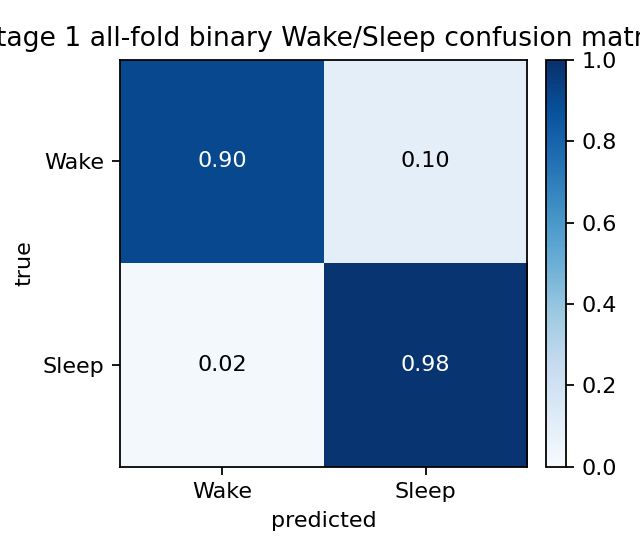


Total training time: 422.70 min (25362.1 sec)


In [ ]:
# Stage 1 summary
from summary_utils import print_stage1_summary

print_stage1_summary(
    Path(SAVE_DIR) / 'kfold20_summary.json',
    elapsed_seconds=globals().get('TRAINING_ELAPSED_SECONDS'),
)


In [ ]:
# Stage 2 delta-flow training + direct inference/eval
if RUN_STAGE2:
    if RUN_STAGE1:
        stage2_stage1_fold_dir = f'{SAVE_DIR}/fold_{STAGE2_FOLD:02d}'
        stage2_stage1_ckpt = f'{stage2_stage1_fold_dir}/best_vae.pt'
    else:
        if not STAGE2_EXISTING_FOLD_DIR or not STAGE2_EXISTING_CKPT:
            raise ValueError('RUN_STAGE1=False requires STAGE2_EXISTING_FOLD_DIR and STAGE2_EXISTING_CKPT')
        stage2_stage1_fold_dir = STAGE2_EXISTING_FOLD_DIR
        stage2_stage1_ckpt = STAGE2_EXISTING_CKPT

    fold_summary_path = Path(stage2_stage1_fold_dir) / "fold_summary.json"
    ckpt_path = Path(stage2_stage1_ckpt)
    print("Stage2 Stage1 fold dir:", stage2_stage1_fold_dir)
    print("Stage2 Stage1 ckpt:", stage2_stage1_ckpt)
    if not fold_summary_path.exists():
        raise FileNotFoundError(f'Missing fold_summary.json for Stage2: {fold_summary_path}')
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Missing Stage1 checkpoint for Stage2: {ckpt_path}')

    stage2_cmd = [
        sys.executable, '-u', 'run_stage2_delta_flow_exclude_stage1_subjects.py',
        '--stage1-fold-dir', stage2_stage1_fold_dir,
        '--stage1-ckpt', stage2_stage1_ckpt,
        '--seed', str(SEED),
        '--stage2-epochs', str(STAGE2_EPOCHS),
        '--stage2-max-subjects', str(STAGE2_MAX_SUBJECTS),
        '--stage2-batch-size', str(STAGE2_BATCH_SIZE),
        '--stage2-context-len', str(STAGE2_CONTEXT_LEN),
        '--stage2-horizons', str(STAGE2_HORIZONS),
        '--stage2-flow-steps', str(STAGE2_FLOW_STEPS),
        '--stage2-lambda-next-stage', str(STAGE2_LAMBDA_NEXT_STAGE),
        '--stage2-sampling', STAGE2_SAMPLING,
        '--stage2-target-stage-weight-multiplier', *map(str, STAGE2_TARGET_STAGE_WEIGHT_MULTIPLIER),
        '--stage2-save-dir', STAGE2_SAVE_DIR,
    ]
    if NO_PROGRESS:
        stage2_cmd += ['--no-progress']
    if STAGE2_INFER_ONLY:
        flow_ckpt_path = Path(STAGE2_FLOW_CKPT)
        print('Stage2 infer-only flow ckpt:', flow_ckpt_path)
        if not flow_ckpt_path.exists():
            raise FileNotFoundError(f'Missing Stage2 flow checkpoint for infer-only: {flow_ckpt_path}')
        stage2_cmd += ['--infer-only', '--flow-ckpt', str(flow_ckpt_path)]
    print(' '.join(stage2_cmd))
    STAGE2_STARTED = time.perf_counter()
    stage2_log_path = Path('/content/stage2_run.log') if Path('/content').exists() else Path('stage2_run.log')
    proc = subprocess.run(stage2_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    stage2_output = proc.stdout or ''
    if stage2_output:
        print(stage2_output)
    stage2_log_saved = False
    try:
        stage2_log_path.write_text(stage2_output, encoding='utf-8')
        stage2_log_saved = True
        print(f'\nStage2 log saved to: {stage2_log_path.resolve()}')
    except OSError as exc:
        print(f'\nStage2 log save skipped: {exc}')
    if proc.returncode != 0:
        if stage2_log_saved:
            print(f'\nStage2 failed with return code {proc.returncode}. Full log: {stage2_log_path.resolve()}')
        else:
            print(f'\nStage2 failed with return code {proc.returncode}. Log was printed above but was not saved.')
        raise RuntimeError(f'Stage2 failed with return code {proc.returncode}')
    STAGE2_ELAPSED_SECONDS = time.perf_counter() - STAGE2_STARTED
    print(f'\nTotal notebook Stage2 cell time: {STAGE2_ELAPSED_SECONDS / 60:.2f} min ({STAGE2_ELAPSED_SECONDS:.1f} sec)')
else:
    print('RUN_STAGE2=False: skipping Stage 2 training')


RUN_STAGE2=False: skipping Stage 2 training


stage2 summary: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_delta_flow_exclude_stage1_h3_summary.json

=== Stage 2 h1 ALL binary Wake/Sleep confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [6652, 653]
Sleep: [159, 3178]
ACC=92.37% MF1=91.46% WakeRecall=91.06% SleepRecall=95.24% n=10642
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h1_all_binary_wake_sleep_confusion.png


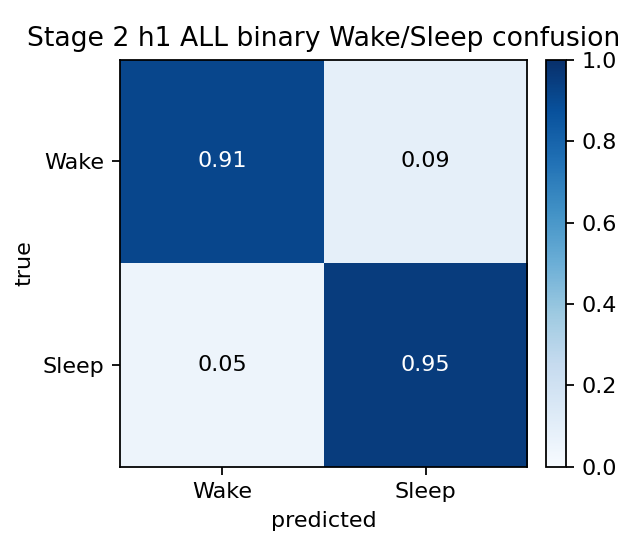


=== Stage 2 h1 W/S TRANSITION-ONLY binary confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [24, 91]
Sleep: [30, 87]
ACC=47.84% MF1=43.69% WakeRecall=20.87% SleepRecall=74.36% n=232
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h1_wake_sleep_boundary_binary_confusion.png


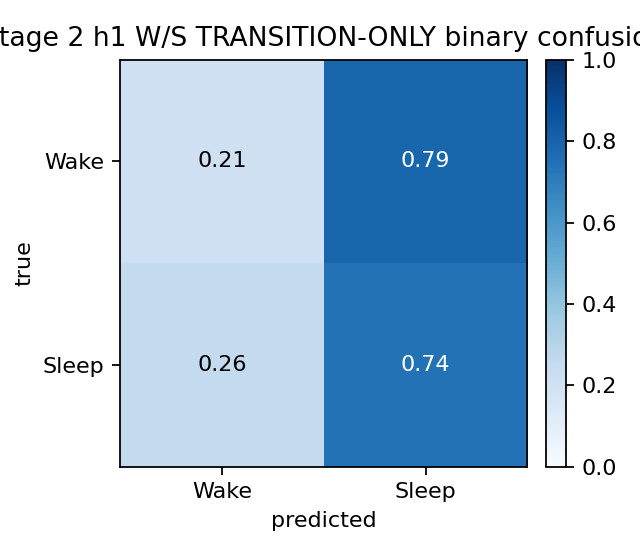


=== Stage 2 h2 ALL binary Wake/Sleep confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [6702, 601]
Sleep: [162, 3177]
ACC=92.83% MF1=91.95% WakeRecall=91.77% SleepRecall=95.15% n=10642
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h2_all_binary_wake_sleep_confusion.png


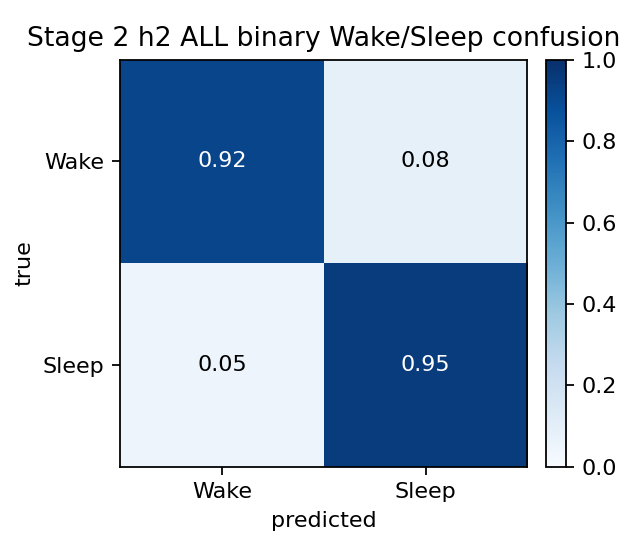


=== Stage 2 h2 W/S TRANSITION-ONLY binary confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [18, 97]
Sleep: [16, 101]
ACC=51.29% MF1=44.14% WakeRecall=15.65% SleepRecall=86.32% n=232
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h2_wake_sleep_boundary_binary_confusion.png


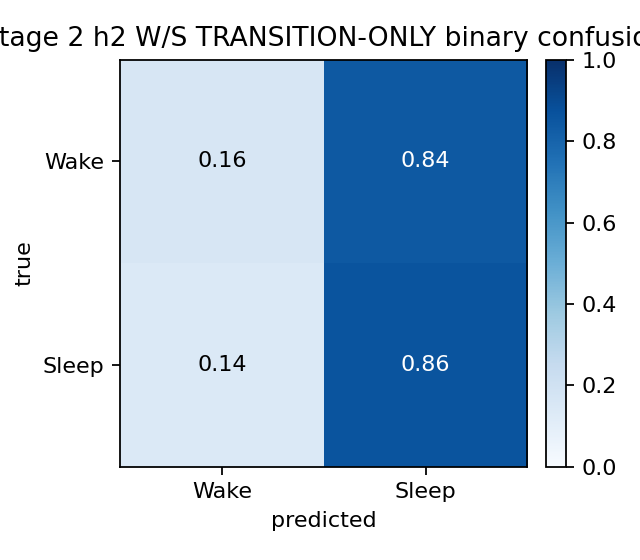


=== Stage 2 h3 ALL binary Wake/Sleep confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [6498, 803]
Sleep: [86, 3255]
ACC=91.65% MF1=90.79% WakeRecall=89.00% SleepRecall=97.43% n=10642
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h3_all_binary_wake_sleep_confusion.png


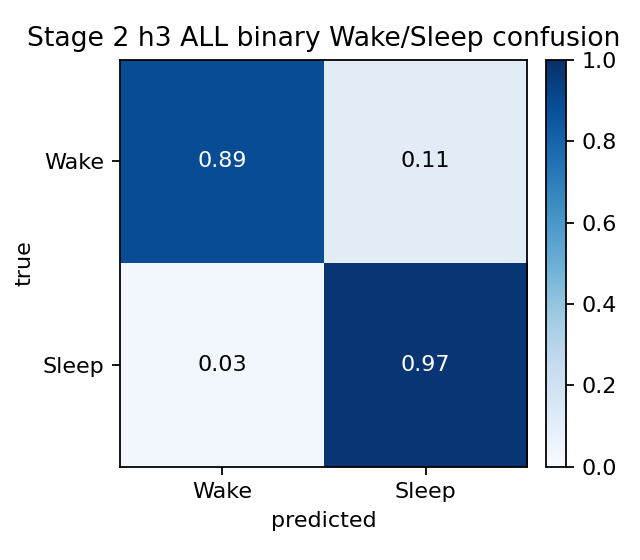


=== Stage 2 h3 W/S TRANSITION-ONLY binary confusion ===
rows=true cols=pred; labels=[Wake, Sleep]
Wake : [12, 103]
Sleep: [15, 102]
ACC=49.14% MF1=40.13% WakeRecall=10.43% SleepRecall=87.18% n=232
visualization: checkpoints/final_model_stage2_delta_flow_transformer_vae_fold13_h3_ctx5_subj30_n1x055_next05/direct_delta_flow_inference/excluded_stage1_test_split/stage2_h3_wake_sleep_boundary_binary_confusion.png


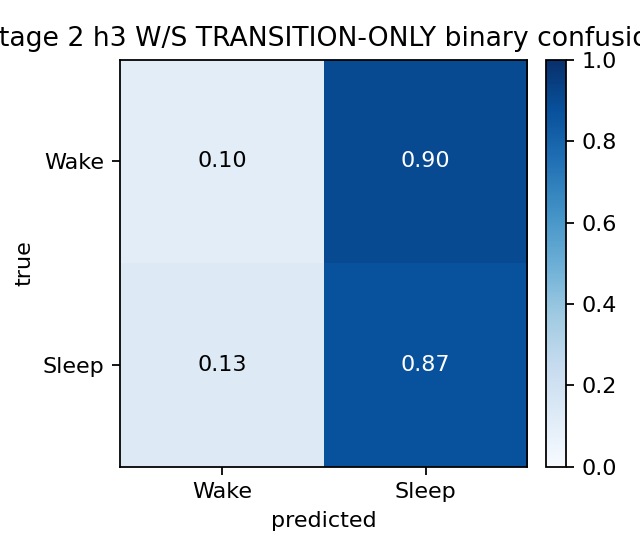


=== Stage 2 3-horizon binary mean ===
ALL: ACC=92.28% MF1=91.40%
W/S TRANSITION: ACC=49.43% MF1=42.65%

=== Stage 2 binary ACC summary ===
| Step | W ACC | S ACC | W->S ACC | S->W ACC | All ACC | W/S Transition ACC |
|---|---:|---:|---:|---:|---:|---:|
| step 1 | 91.06% | 95.24% | 74.36% | 20.87% | 92.37% | 47.84% |
| step 2 | 91.77% | 95.15% | 86.32% | 15.65% | 92.83% | 51.29% |
| step 3 | 89.00% | 97.43% | 87.18% | 10.43% | 91.65% | 49.14% |
| Mean | 90.61% | 95.94% | 82.62% | 15.65% | 92.28% | 49.43% |


In [ ]:
# Stage 2 summary
from summary_utils import print_stage2_summary

print_stage2_summary(STAGE2_SAVE_DIR, STAGE2_HORIZONS)
